In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

import warnings
import joblib
import os

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

CURRENT_YEAR = 2024



In [27]:
print("\n[1] LOADING DATASET...")
FILE_PATH = "car data.csv"

if not os.path.exists(FILE_PATH):
    try:
        import gdown
        url = "https://drive.google.com/uc?id=1yFuNVPXM5CH6g0TthYKcTGrZCCJo6n8Z"
        gdown.download(url, FILE_PATH, quiet=False)
        print("   Dataset downloaded successfully.")
    except Exception as e:
        raise FileNotFoundError(
            f"Auto-download failed ({e}).\n"
            "Please download 'car data.csv' manually and place it in the same folder."
        )

df = pd.read_csv(FILE_PATH)
print(f"   Shape       : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"   Columns     : {list(df.columns)}")
print("\n   First 5 rows:")
print(df.head())



[1] LOADING DATASET...
   Shape       : 301 rows × 9 columns
   Columns     : ['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']

   First 5 rows:
  Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Seller_Type Transmission  Owner  
0      Dealer       Manual      0  
1      Dealer       Manual      0  
2      Dealer       Manual      0  
3      Dealer       Manual      0  
4      Dealer       Manual      0  


In [28]:
print("\n[2] DATA PREPROCESSING...")

print("\n   Dataset Info:")
print(df.info())
print(f"\n   Missing Values:\n{df.isnull().sum()}")


if "Car_Name" in df.columns:
    df.drop(columns=["Car_Name"], inplace=True)
    print("\n   Dropped column: Car_Name")


df["Years_Since_Manufacture"] = CURRENT_YEAR - df["Year"]
df.drop(columns=["Year"], inplace=True)
print("   Derived feature: Years_Since_Manufacture")


for col in df.select_dtypes(include=[np.number]).columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)
        print(f"   Filled missing numerical values in: {col}")


for col in df.select_dtypes(include=["object"]).columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)
        print(f"   Filled missing categorical values in: {col}")


before = len(df)
df.drop_duplicates(inplace=True)
print(f"   Removed {before - len(df)} duplicate rows.")


Q1 = df["Selling_Price"].quantile(0.25)
Q3 = df["Selling_Price"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
before = len(df)
df = df[(df["Selling_Price"] >= lower) & (df["Selling_Price"] <= upper)].copy()
print(f"   Removed {before - len(df)} outliers from Selling_Price (IQR method).")

print(f"\n   Clean dataset shape: {df.shape}")
print("\n   Statistical Summary:")
print(df.describe())



[2] DATA PREPROCESSING...

   Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB
None

   Missing Values:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

   Dropped column: Car_Name
   Derived feature: Years_Since_Manufacture
   Removed 2 duplicate


[3] EXPLORATORY DATA ANALYSIS...


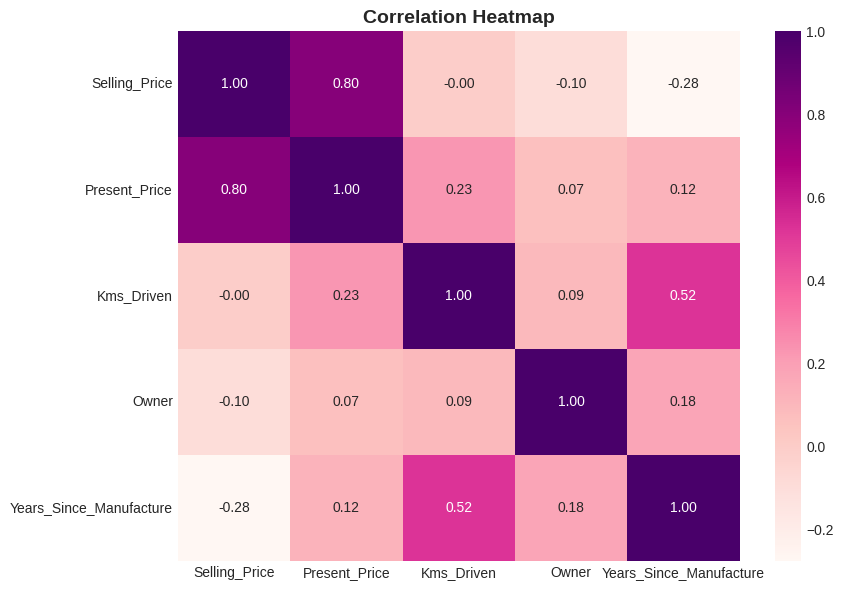

In [29]:
print("\n[3] EXPLORATORY DATA ANALYSIS...")


fig1 = px.histogram(
    df, x="Selling_Price", nbins=40,
    title="Distribution of Car Selling Prices",
    labels={"Selling_Price": "Selling Price (in Lakhs)"},
    color_discrete_sequence=["#6C3FC8"]
)
fig1.update_layout(bargap=0.05)
fig1.show()


fig2 = px.box(
    df, x="Fuel_Type", y="Selling_Price",
    title="Selling Price by Fuel Type",
    color="Fuel_Type",
    labels={"Selling_Price": "Selling Price (Lakhs)"}
)
fig2.show()


fig3 = px.box(
    df, x="Transmission", y="Selling_Price",
    title="Selling Price by Transmission Type",
    color="Transmission",
    labels={"Selling_Price": "Selling Price (Lakhs)"}
)
fig3.show()


fig4 = px.violin(
    df, x="Seller_Type", y="Selling_Price",
    title="Selling Price by Seller Type",
    color="Seller_Type", box=True,
    labels={"Selling_Price": "Selling Price (Lakhs)"}
)
fig4.show()


fig5 = px.scatter(
    df, x="Kms_Driven", y="Selling_Price",
    color="Fuel_Type", size="Present_Price",
    title="Kms Driven vs Selling Price",
    labels={"Selling_Price": "Selling Price (Lakhs)", "Kms_Driven": "Kilometers Driven"},
    opacity=0.7
)
fig5.show()


numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

fig6, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdPu", ax=ax)
ax.set_title("Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


fig7 = px.scatter(
    df, x="Years_Since_Manufacture", y="Selling_Price",
    color="Transmission",
    title="Years Since Manufacture vs Selling Price",
    labels={"Selling_Price": "Selling Price (Lakhs)"},
    opacity=0.7
)

z = np.polyfit(df["Years_Since_Manufacture"], df["Selling_Price"], 1)
p = np.poly1d(z)
x_range = np.linspace(df["Years_Since_Manufacture"].min(), df["Years_Since_Manufacture"].max(), 100)
fig7.add_trace(go.Scatter(
    x=x_range, y=p(x_range),
    mode="lines", name="OLS Trendline",
    line=dict(color="black", dash="dash", width=2)
))
fig7.show()


In [30]:
print("\n[4] FEATURE ENGINEERING...")

categorical_cols = ["Fuel_Type", "Seller_Type", "Transmission"]


label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
    print(f"   Encoded: {col}  →  classes: {list(le.classes_)}")

X = df.drop(columns=["Selling_Price"])
y = df["Selling_Price"]

print(f"\n   Features used : {list(X.columns)}")
print(f"   Target        : Selling_Price")
print(f"   X shape       : {X.shape}")
print(f"   y shape       : {y.shape}")


FEATURE_COLUMNS = list(X.columns)


[4] FEATURE ENGINEERING...
   Encoded: Fuel_Type  →  classes: ['CNG', 'Diesel', 'Petrol']
   Encoded: Seller_Type  →  classes: ['Dealer', 'Individual']
   Encoded: Transmission  →  classes: ['Automatic', 'Manual']

   Features used : ['Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner', 'Years_Since_Manufacture']
   Target        : Selling_Price
   X shape       : (283, 7)
   y shape       : (283,)


In [31]:
print("\n[5] SPLITTING DATA...")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"   Training set  : {X_train.shape[0]} samples")
print(f"   Testing set   : {X_test.shape[0]} samples")



[5] SPLITTING DATA...
   Training set  : 226 samples
   Testing set   : 57 samples


In [32]:
print("\n[6] MODEL SELECTION: Random Forest Regressor")

baseline_rf = RandomForestRegressor(n_estimators=100, random_state=42)
baseline_rf.fit(X_train, y_train)
baseline_pred = baseline_rf.predict(X_test)

baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2   = r2_score(y_test, baseline_pred)
print(f"   Baseline RMSE : {baseline_rmse:.4f}")
print(f"   Baseline R²   : {baseline_r2:.4f}")


[6] MODEL SELECTION: Random Forest Regressor
   Baseline RMSE : 0.7161
   Baseline R²   : 0.9299


In [33]:
print("\n[7] HYPERPARAMETER TUNING")

param_dist = {
    "n_estimators"      : [50, 100, 200, 300, 500],
    "max_depth"         : [None, 5, 10, 15, 20],
    "min_samples_split" : [2, 5, 10],
    "min_samples_leaf"  : [1, 2, 4],
    "max_features"      : ["sqrt", "log2", None],
    "bootstrap"         : [True, False]
}

rf = RandomForestRegressor(random_state=42)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring="neg_mean_squared_error",
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print(f"\n   Best Parameters: {random_search.best_params_}")



[7] HYPERPARAMETER TUNING
Fitting 5 folds for each of 50 candidates, totalling 250 fits

   Best Parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 10, 'bootstrap': True}


In [34]:
print("\n[8] TRAINING FINAL MODEL...")

best_rf = random_search.best_estimator_
best_rf.fit(X_train, y_train)

cv_scores = cross_val_score(best_rf, X_train, y_train, cv=5, scoring="r2")
print(f"   Cross-Val R² scores : {cv_scores.round(4)}")
print(f"   Mean CV R²          : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


[8] TRAINING FINAL MODEL...
   Cross-Val R² scores : [0.9283 0.9427 0.9457 0.9491 0.9177]
   Mean CV R²          : 0.9367 ± 0.0119


In [35]:
print("\n[9] MODEL EVALUATION...")

y_pred = best_rf.predict(X_test)

mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print(f"   │  MSE   : {mse:.4f}")
print(f"   │  RMSE  : {rmse:.4f}")
print(f"   │  MAE   : {mae:.4f}")
print(f"   │  R²    : {r2:.4f}")


fig8 = px.scatter(
    x=y_test, y=y_pred,
    labels={"x": "Actual Price (Lakhs)", "y": "Predicted Price (Lakhs)"},
    title="Actual vs Predicted Selling Prices",
    opacity=0.7,
    color_discrete_sequence=["#6C3FC8"]
)
fig8.add_shape(
    type="line",
    x0=y_test.min(), y0=y_test.min(),
    x1=y_test.max(), y1=y_test.max(),
    line=dict(color="red", dash="dash", width=2)
)
fig8.show()


residuals = y_test - y_pred
fig9 = px.scatter(
    x=y_pred, y=residuals,
    labels={"x": "Predicted Price", "y": "Residuals"},
    title="Residuals vs Predicted Values",
    color_discrete_sequence=["#E91E8C"],
    opacity=0.7
)
fig9.add_hline(y=0, line_dash="dash", line_color="black")
fig9.show()


feature_importance = pd.DataFrame({
    "Feature"   : X.columns,
    "Importance": best_rf.feature_importances_
}).sort_values("Importance", ascending=False)

fig10 = px.bar(
    feature_importance, x="Importance", y="Feature",
    orientation="h",
    title="Feature Importances (Random Forest)",
    color="Importance",
    color_continuous_scale="RdPu"
)
fig10.show()

print("\n   Feature Importances:")
print(feature_importance.to_string(index=False))


[9] MODEL EVALUATION...
   │  MSE   : 0.4726
   │  RMSE  : 0.6874
   │  MAE   : 0.4369
   │  R²    : 0.9354



   Feature Importances:
                Feature  Importance
          Present_Price    0.829812
Years_Since_Manufacture    0.115187
             Kms_Driven    0.035840
              Fuel_Type    0.010630
            Seller_Type    0.006847
           Transmission    0.001625
                  Owner    0.000059


In [36]:
print("\n[10] SAVING MODEL...")

joblib.dump(best_rf, "car_price_model.pkl")
joblib.dump(label_encoders, "label_encoders.pkl")

joblib.dump(FEATURE_COLUMNS, "feature_columns.pkl")

print("   Model saved    : car_price_model.pkl")
print("   Encoders saved : label_encoders.pkl")
print("   Feature order  : feature_columns.pkl")



[10] SAVING MODEL...
   Model saved    : car_price_model.pkl
   Encoders saved : label_encoders.pkl
   Feature order  : feature_columns.pkl


In [37]:
def predict_selling_price(
    present_price,
    kms_driven,
    owner,
    fuel_type,
    seller_type,
    transmission,
    year_of_purchase
):

    model    = joblib.load("car_price_model.pkl")
    encoders = joblib.load("label_encoders.pkl")
    feature_cols = joblib.load("feature_columns.pkl")


    years_since = CURRENT_YEAR - year_of_purchase


    fuel_enc   = encoders["Fuel_Type"].transform([fuel_type])[0]
    seller_enc = encoders["Seller_Type"].transform([seller_type])[0]
    trans_enc  = encoders["Transmission"].transform([transmission])[0]


    raw = {
        "Present_Price"          : present_price,
        "Kms_Driven"             : kms_driven,
        "Fuel_Type"              : fuel_enc,
        "Seller_Type"            : seller_enc,
        "Transmission"           : trans_enc,
        "Owner"                  : owner,
        "Years_Since_Manufacture": years_since
    }
    input_data = pd.DataFrame([raw])[feature_cols]

    prediction = model.predict(input_data)[0]
    return round(prediction, 2)


In [38]:
print("\n[11] SAMPLE PREDICTION TEST...")

sample_price = predict_selling_price(
    present_price=5.59,
    kms_driven=27000,
    owner=0,
    fuel_type="Petrol",
    seller_type="Dealer",
    transmission="Manual",
    year_of_purchase=2014
)
print(f"   Sample Predicted Selling Price: ₹ {sample_price} Lakhs")


[11] SAMPLE PREDICTION TEST...
   Sample Predicted Selling Price: ₹ 3.77 Lakhs
